# E-Commerce Sales Data Analysis & Profitability Dashboard
**Objective:** To analyze 3 years of e-commerce transaction data (2023-2025) to identify top-performing products, visualize revenue trends, and determine how aggressive discounting impacts overall business profitability.

In [194]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [195]:
df = pd.read_csv("Ecommerce_Sales_Data_2024_2025.csv")

## Step 1: Data Acquisition & Preprocessing
Before analysis, we must ensure our dataset is clean. This step involves loading the raw `Ecommerce_Sales_Data_2024_2025.csv`, handling missing values to prevent data dropping, and casting dates into a machine-readable format.

In [196]:
df.head()

,Order ID,Order Date,Customer Name,Region,City,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode
0,10001,2024-10-19,Kashvi Varty,South,Bangalore,Books,Non-Fiction,Non-Fiction Ipsum,2,36294,5,68958.6,10525.09,Debit Card
1,10002,2025-08-30,Advik Desai,North,Delhi,Groceries,Rice,Rice Nemo,1,42165,20,33732.0,6299.66,Debit Card
2,10003,2023-11-04,Rhea Kalla,East,Patna,Kitchen,Juicer,Juicer Odio,4,64876,20,207603.2,19850.27,Credit Card
3,10004,2025-05-23,Anika Sen,East,Kolkata,Groceries,Oil,Oil Doloribus,5,37320,15,158610.0,36311.02,UPI
4,10005,2025-01-19,Akarsh Kaul,West,Pune,Clothing,Kids Wear,Kids Wear Quo,1,50037,10,45033.3,9050.04,Debit Card


In [197]:
df.columns

Index(['Order ID', 'Order Date', 'Customer Name', 'Region', 'City', 'Category',
       'Sub-Category', 'Product Name', 'Quantity', 'Unit Price', 'Discount',
       'Sales', 'Profit', 'Payment Mode'],
      dtype='object')

In [198]:
df['Category'].value_counts()

Category
Books          528
Kitchen        528
Furniture      527
Home Decor     515
Clothing       511
Sports         511
Toys           478
Electronics    472
Groceries      470
Beauty         460
Name: count, dtype: int64

In [199]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       5000 non-null   int64  
 1   Order Date     5000 non-null   object 
 2   Customer Name  5000 non-null   object 
 3   Region         5000 non-null   object 
 4   City           5000 non-null   object 
 5   Category       5000 non-null   object 
 6   Sub-Category   5000 non-null   object 
 7   Product Name   5000 non-null   object 
 8   Quantity       5000 non-null   int64  
 9   Unit Price     5000 non-null   int64  
 10  Discount       5000 non-null   int64  
 11  Sales          5000 non-null   float64
 12  Profit         5000 non-null   float64
 13  Payment Mode   5000 non-null   object 
dtypes: float64(2), int64(4), object(8)
memory usage: 547.0+ KB


In [200]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [201]:
df.isna().sum()

Order ID         0
Order Date       0
Customer Name    0
Region           0
City             0
Category         0
Sub-Category     0
Product Name     0
Quantity         0
Unit Price       0
Discount         0
Sales            0
Profit           0
Payment Mode     0
dtype: int64

In [202]:
df.drop('Payment Mode',axis=1,inplace=True)

In [203]:
df.duplicated(subset='Order ID').sum()

np.int64(0)

In [204]:
print("--- Data Cleaning Complete ---")
print(df.info())
display(df.head())

--- Data Cleaning Complete ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       5000 non-null   int64         
 1   Order Date     5000 non-null   datetime64[ns]
 2   Customer Name  5000 non-null   object        
 3   Region         5000 non-null   object        
 4   City           5000 non-null   object        
 5   Category       5000 non-null   object        
 6   Sub-Category   5000 non-null   object        
 7   Product Name   5000 non-null   object        
 8   Quantity       5000 non-null   int64         
 9   Unit Price     5000 non-null   int64         
 10  Discount       5000 non-null   int64         
 11  Sales          5000 non-null   float64       
 12  Profit         5000 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(4), object(6)
memory usage: 507.9+ KB
None


,Order ID,Order Date,Customer Name,Region,City,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit
0,10001,2024-10-19,Kashvi Varty,South,Bangalore,Books,Non-Fiction,Non-Fiction Ipsum,2,36294,5,68958.6,10525.09
1,10002,2025-08-30,Advik Desai,North,Delhi,Groceries,Rice,Rice Nemo,1,42165,20,33732.0,6299.66
2,10003,2023-11-04,Rhea Kalla,East,Patna,Kitchen,Juicer,Juicer Odio,4,64876,20,207603.2,19850.27
3,10004,2025-05-23,Anika Sen,East,Kolkata,Groceries,Oil,Oil Doloribus,5,37320,15,158610.0,36311.02
4,10005,2025-01-19,Akarsh Kaul,West,Pune,Clothing,Kids Wear,Kids Wear Quo,1,50037,10,45033.3,9050.04


## Step 2: High-Level Business Metrics (EDA)
Here, we extract the absolute core metrics of the business. Understanding the total scale of Revenue and Profit gives us a baseline before we dive into granular product analysis.

In [205]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()

print("--- Overall Business Metrics ---")
print(f"Total Sales Revenue: ₹{total_sales:,.2f}")
print(f"Total Profit: ₹{total_profit:,.2f}\n")

regional_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
print("--- Regional Sales Distribution ---")
print(regional_sales)

--- Overall Business Metrics ---
Total Sales Revenue: ₹533,666,024.35
Total Profit: ₹79,708,734.91

--- Regional Sales Distribution ---
Region
North    1.435782e+08
East     1.358116e+08
West     1.310460e+08
South    1.232302e+08
Name: Sales, dtype: float64


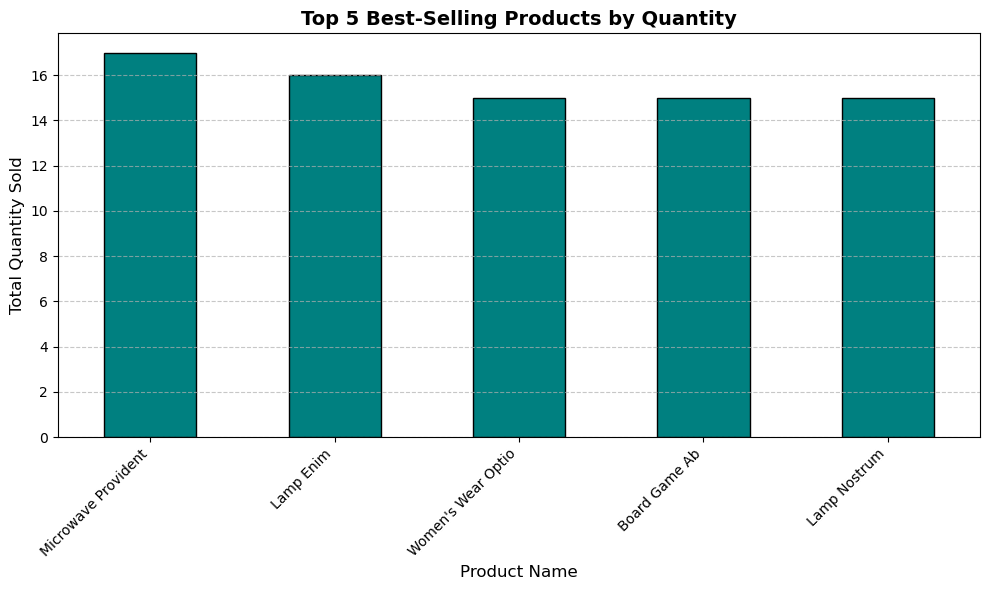

In [206]:
plt.figure(figsize=(10, 6))

top_5_products = df.groupby('Product Name')['Quantity'].sum().sort_values(ascending=False).head(5)

top_5_products.plot(kind='bar', color='teal', edgecolor='black')

plt.title('Top 5 Best-Selling Products by Quantity', fontsize=14, fontweight='bold')
plt.xlabel('Product Name', fontsize=12)
plt.ylabel('Total Quantity Sold', fontsize=12)

plt.xticks(rotation=45, ha='right') 
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [207]:
unique_years = sorted(df['Order Date'].dt.year.unique())

print("Years present in the dataset:", unique_years)
print("Total number of years:", len(unique_years))

Years present in the dataset: [np.int32(2023), np.int32(2024), np.int32(2025)]
Total number of years: 3


In [208]:
top_revenue = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

top_units = df.groupby('Product Name')['Quantity'].sum().sort_values(ascending=False).head(10)

category_perf = df.groupby('Category')[['Sales', 'Profit']].sum().sort_values(by='Sales', ascending=False)


print("--- TOP 5 BY REVENUE ---")
print(top_revenue.head(5), "\n")

print("--- TOP 5 BY UNITS SOLD ---")
print(top_units.head(5), "\n")

print("--- CATEGORY PERFORMANCE ---")
print(category_perf, "\n")

--- TOP 5 BY REVENUE ---
Product Name
Headphones Accusantium     857184.20
Spices Quibusdam           687651.25
Accessories Repellendus    687083.30
Bed Tenetur                670994.80
Laptop Similique           666640.60
Name: Sales, dtype: float64 

--- TOP 5 BY UNITS SOLD ---
Product Name
Microwave Provident    17
Lamp Enim              16
Women's Wear Optio     15
Board Game Ab          15
Lamp Nostrum           15
Name: Quantity, dtype: int64 

--- CATEGORY PERFORMANCE ---
                   Sales      Profit
Category                            
Home Decor   57233222.35  8556846.94
Furniture    56647187.90  8693087.03
Clothing     55053908.30  8445750.29
Books        54932643.00  8076273.29
Kitchen      54227902.30  7879573.29
Electronics  52587883.95  8042133.88
Toys         52227366.45  7986871.44
Sports       52069397.25  7739430.04
Beauty       50803409.70  7213436.07
Groceries    47883103.15  7075332.64 



## Step 3: Product & Category Performance
To understand what drives the business, we must look at our assets from two angles: **Revenue** (money in) and **Volume** (units moved). We will also evaluate entire categories to see which sectors are yielding the highest profit margins.

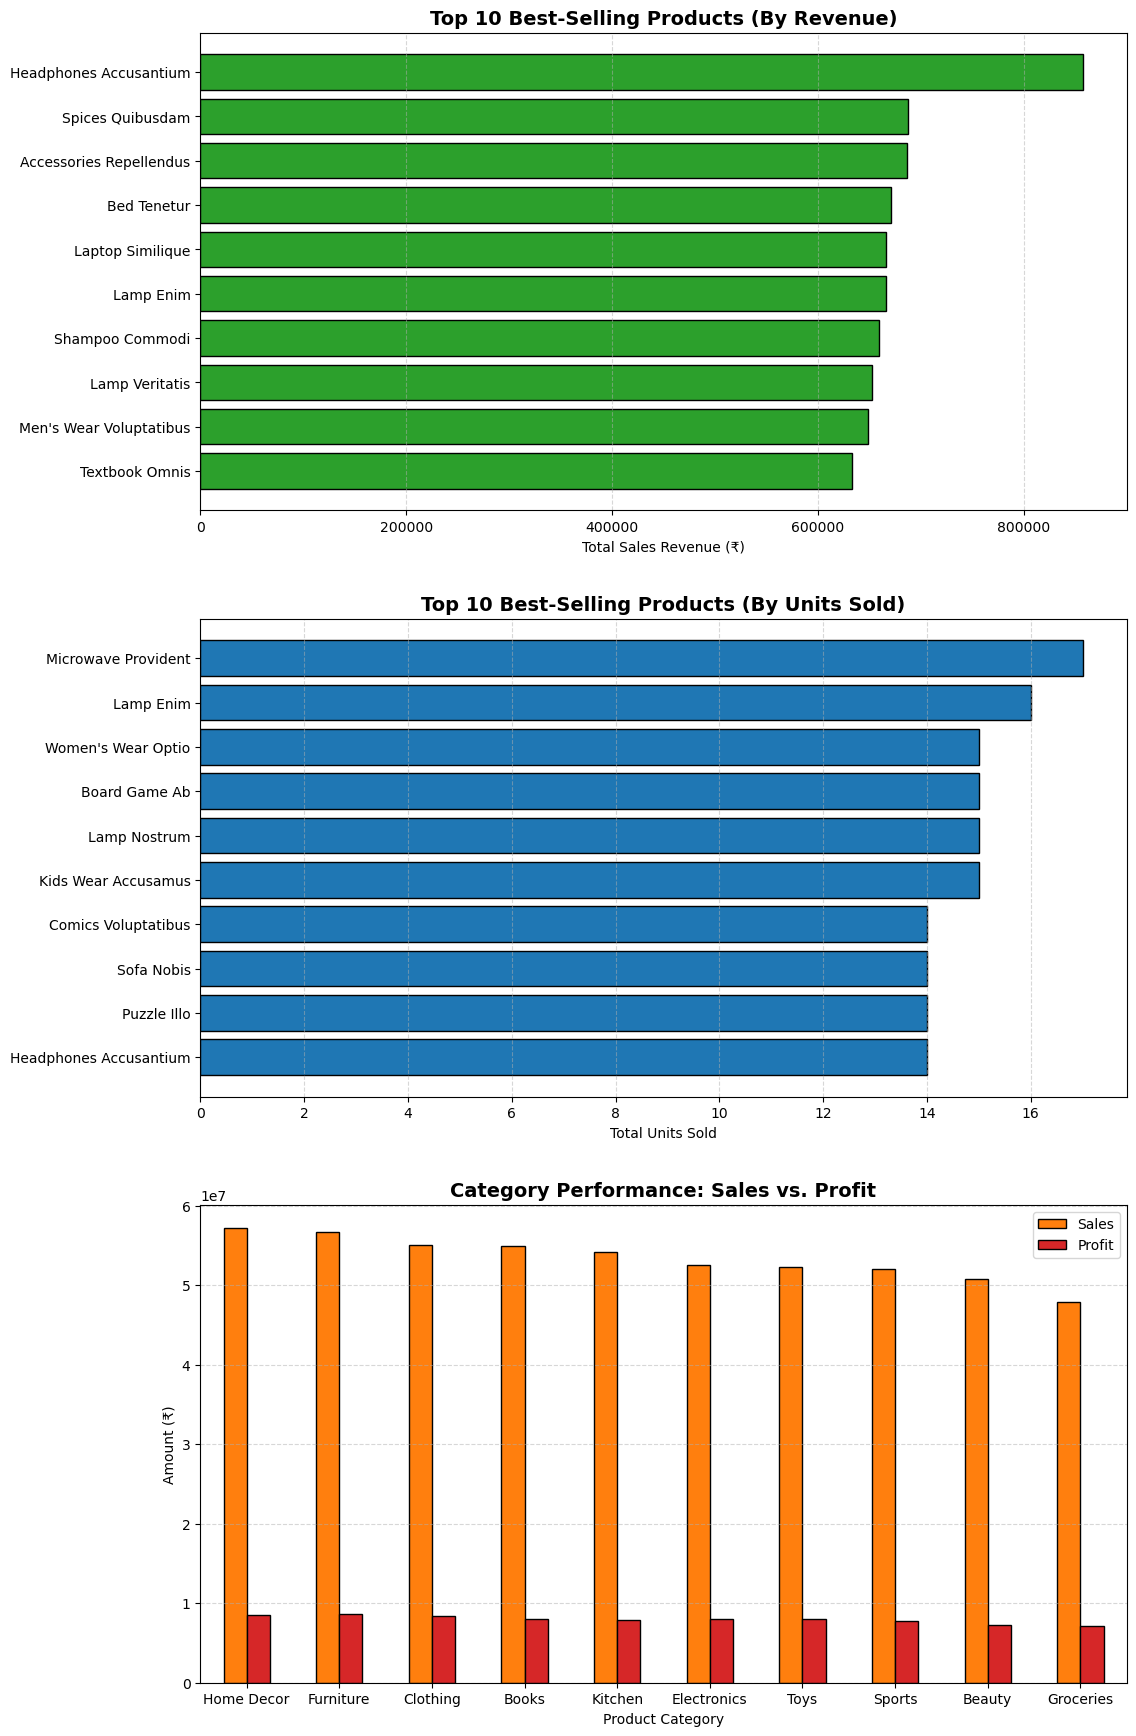

In [209]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 18))


axes[0].barh(top_revenue.index, top_revenue.values, color='#2ca02c', edgecolor='black')
axes[0].invert_yaxis() 
axes[0].set_title('Top 10 Best-Selling Products (By Revenue)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Total Sales Revenue (₹)')
axes[0].grid(axis='x', linestyle='--', alpha=0.5)


axes[1].barh(top_units.index, top_units.values, color='#1f77b4', edgecolor='black')
axes[1].invert_yaxis()
axes[1].set_title('Top 10 Best-Selling Products (By Units Sold)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Total Units Sold')
axes[1].grid(axis='x', linestyle='--', alpha=0.5)


category_perf.plot(kind='bar', ax=axes[2], color=['#ff7f0e', '#d62728'], edgecolor='black')
axes[2].set_title('Category Performance: Sales vs. Profit', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Amount (₹)')
axes[2].set_xlabel('Product Category')
axes[2].tick_params(axis='x', rotation=0) 
axes[2].grid(axis='y', linestyle='--', alpha=0.5)


plt.tight_layout(pad=3.0)
plt.show()

## Step 4: Time-Series Analysis (Year-Over-Year Trends)
Sales do not happen in a vacuum; they are seasonal. By extracting the Year and Month from our datetime objects, we can build a dashboard that tracks our monthly revenue trajectory individually for 2023, 2024, and 2025, culminating in a combined Year-over-Year (YoY) comparison.

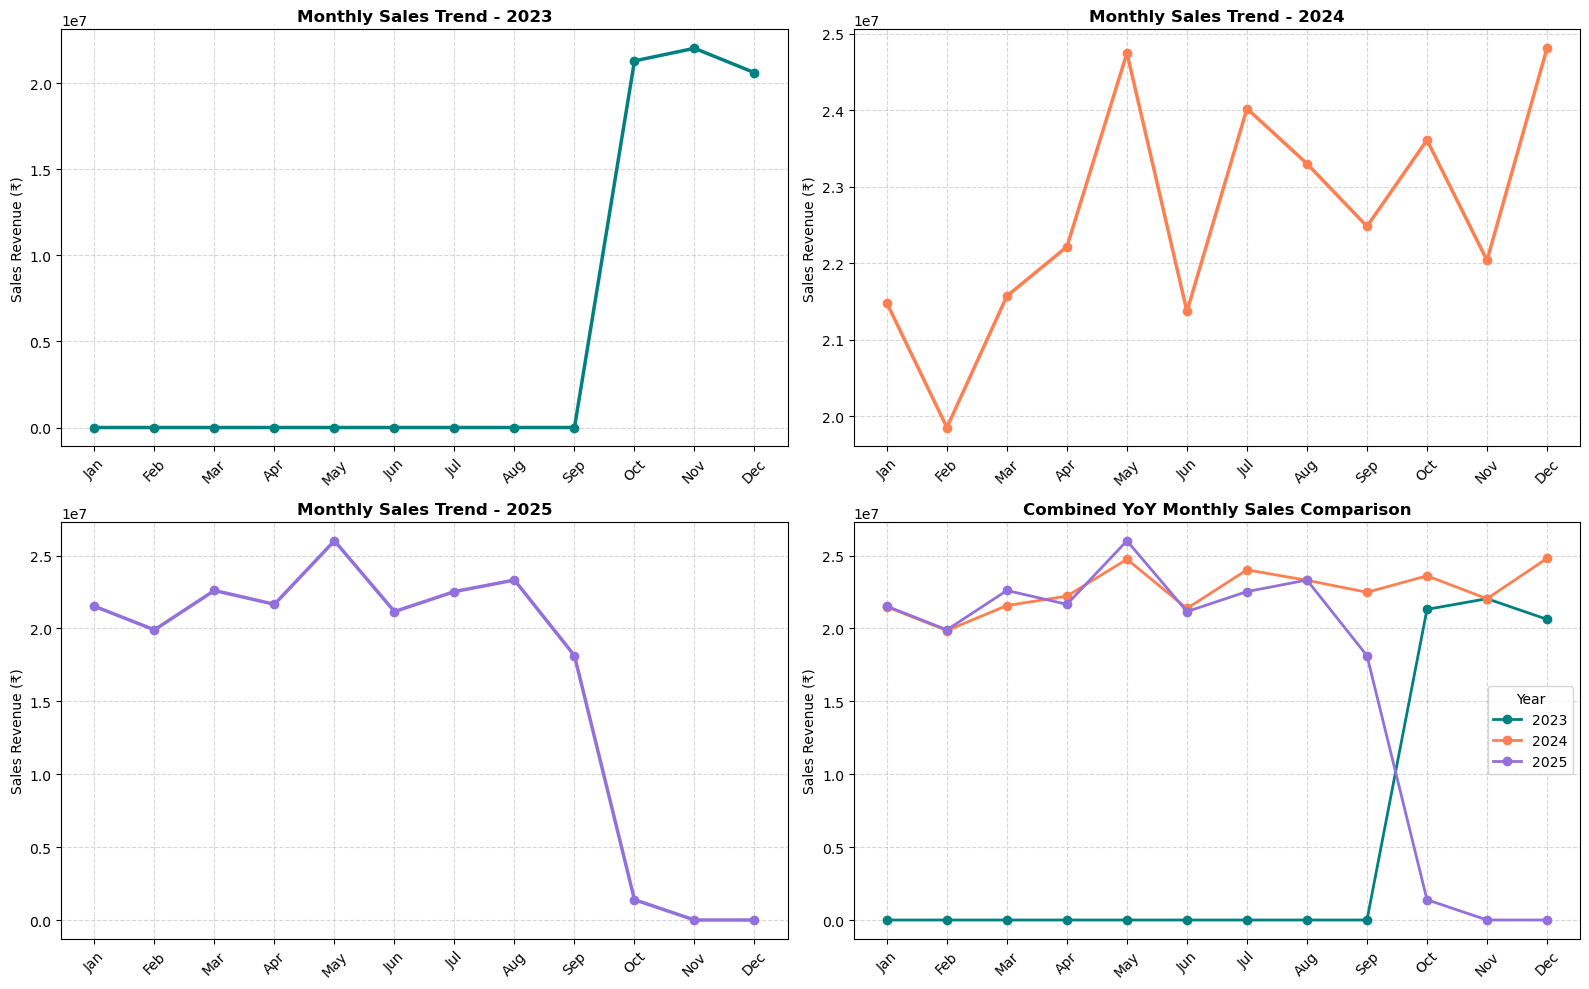

In [210]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

years = sorted(df['Year'].unique())
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))
axes = axes.flatten()

colors = ['teal', 'coral', 'mediumpurple'] 

for i, year in enumerate(years):
    yearly_data = df[df['Year'] == year]

    monthly_trend = yearly_data.groupby('Month')['Sales'].sum().reindex(range(1, 13), fill_value=0)
    
    axes[i].plot(monthly_trend.index, monthly_trend.values, 
                 color=colors[i], marker='o', linewidth=2.5)
    
    axes[i].set_title(f'Monthly Sales Trend - {year}', fontsize=12, fontweight='bold')
    axes[i].set_xticks(range(1, 13))
    axes[i].set_xticklabels(month_names, rotation=45)
    axes[i].set_ylabel('Sales Revenue (₹)')
    axes[i].grid(True, linestyle='--', alpha=0.5)

for i, year in enumerate(years):
    yearly_data = df[df['Year'] == year]
    monthly_trend = yearly_data.groupby('Month')['Sales'].sum().reindex(range(1, 13), fill_value=0)
    
    
    axes[3].plot(monthly_trend.index, monthly_trend.values, 
                 color=colors[i], marker='o', linewidth=2, label=str(year))


axes[3].set_title('Combined YoY Monthly Sales Comparison', fontsize=12, fontweight='bold')
axes[3].set_xticks(range(1, 13))
axes[3].set_xticklabels(month_names, rotation=45)
axes[3].set_ylabel('Sales Revenue (₹)')
axes[3].grid(True, linestyle='--', alpha=0.5)


axes[3].legend(title='Year', loc='best')

plt.tight_layout()
plt.show()

## Step 5: Metric Correlations
Using a Seaborn Heatmap, we will mathematically calculate how our numerical columns interact. This allows us to instantly spot negative correlations—such as whether applying discounts is actively harming our profit.

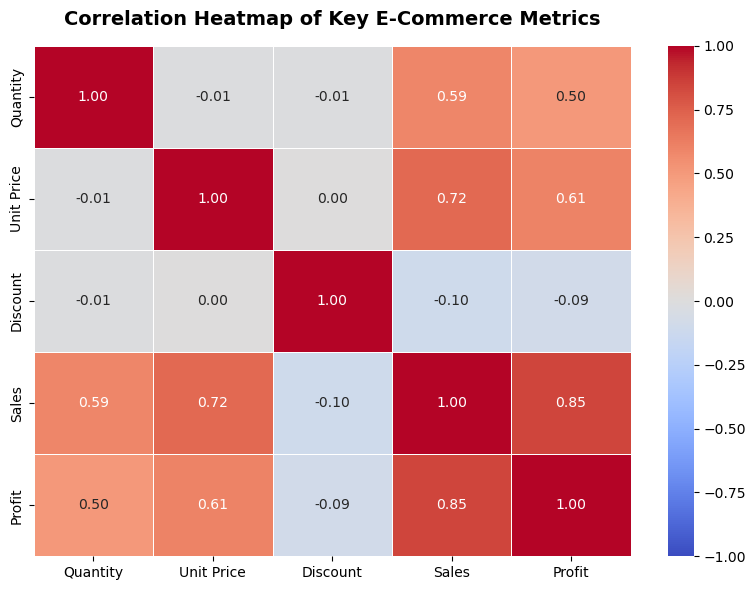

In [211]:
best_columns = ['Quantity', 'Unit Price', 'Discount', 'Sales', 'Profit']

plt.figure(figsize=(8, 6))

corr_matrix = df[best_columns].corr()

sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='coolwarm', 
            fmt=".2f", 
            linewidths=0.5, 
            vmin=-1, 
            vmax=1)

plt.title('Correlation Heatmap of Key E-Commerce Metrics', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## Step 6: Profit Drivers & Discounting Impact (Regression Analysis)
To prove the insights found in our heatmap, we apply regression trendlines year-by-year. 
* **Sales vs. Profit:** We filter out massive wholesale outliers (`Sales < 3000`) to find the true baseline profitability of standard daily orders.
* **Discount vs. Profit:** We use `jitter` to un-stack fixed discount percentages, allowing us to see exactly where our profit drops below zero (represented by the black baseline).

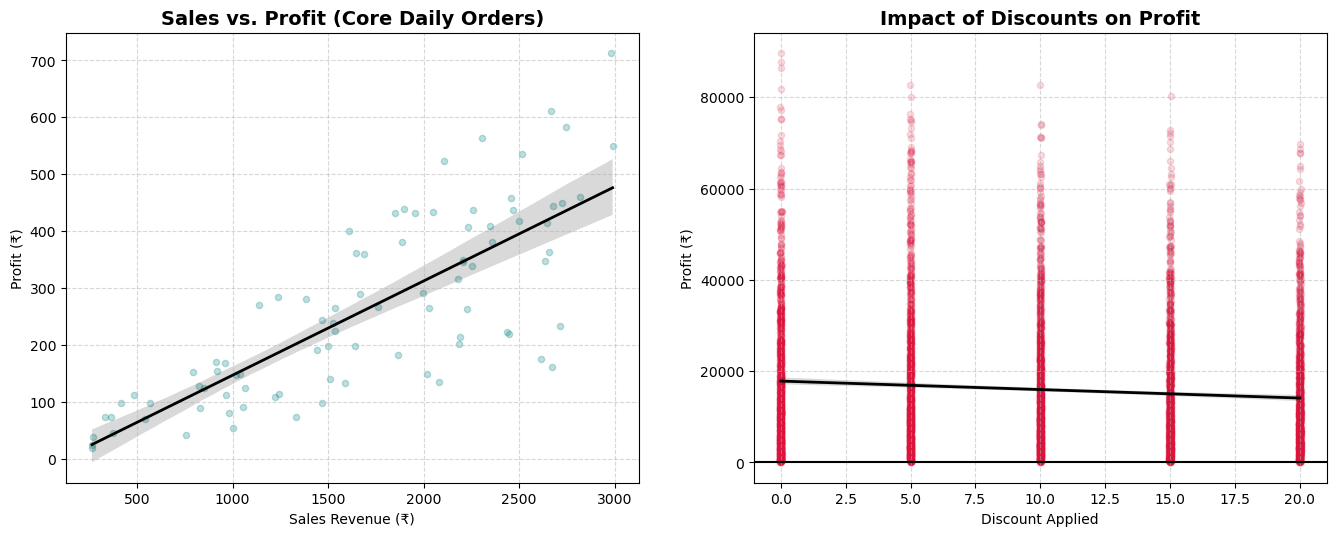

In [212]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

normal_sales = df[df['Sales'] < 3000]

sns.regplot(data=normal_sales, x='Sales', y='Profit', ax=axes[0], 
            scatter_kws={'alpha': 0.25, 'color': 'teal', 's': 20}, 
            line_kws={'color': 'black', 'linewidth': 2})

axes[0].set_title('Sales vs. Profit (Core Daily Orders)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sales Revenue (₹)')
axes[0].set_ylabel('Profit (₹)')
axes[0].grid(True, linestyle='--', alpha=0.5)

sns.regplot(data=df, x='Discount', y='Profit', ax=axes[1], 
            x_jitter=0.03, 
            scatter_kws={'alpha': 0.15, 'color': 'crimson', 's': 20}, 
            line_kws={'color': 'black', 'linewidth': 2})

axes[1].set_title('Impact of Discounts on Profit', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Discount Applied')
axes[1].set_ylabel('Profit (₹)')
axes[1].grid(True, linestyle='--', alpha=0.5)

axes[1].axhline(0, color='black', linestyle='-', linewidth=1.5)

plt.tight_layout(pad=3.0)
plt.show()

## Step 7: Regional Sales Distribution
Finally, we visualize our geographic footprint. This highlights which regions are our strongest markets and where we might need to focus future marketing efforts.

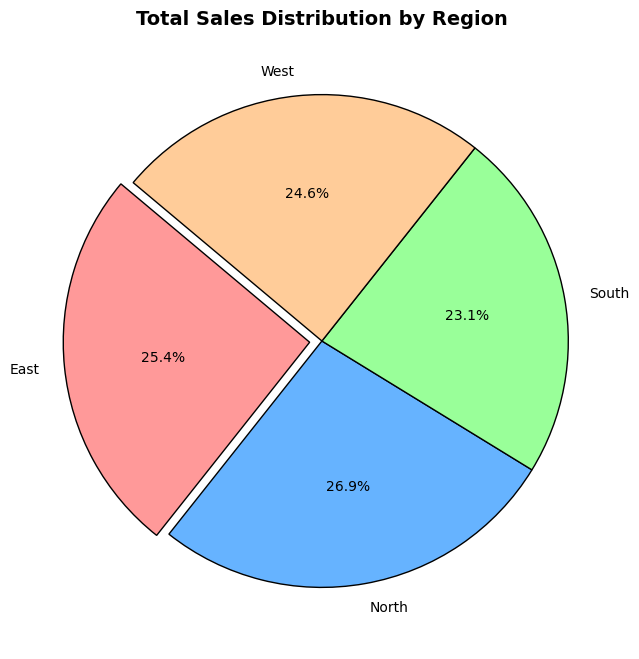

In [213]:
plt.figure(figsize=(8, 8))

regional_sales = df.groupby('Region')['Sales'].sum()

plt.pie(regional_sales.values, 
        labels=regional_sales.index, 
        autopct='%1.1f%%', 
        startangle=140, 
        explode=[0.05, 0, 0, 0], 
        colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'],
        wedgeprops={'edgecolor': 'black'})

plt.title('Total Sales Distribution by Region', fontsize=14, fontweight='bold')
plt.show()

## Executive Summary & Business Insights
Based on the visual data analysis, we can conclude:
1. **Discounting is Dangerous:** The regression analysis mathematically proves that higher discount tiers aggressively push the company into negative profit margins.
2. **Volume ≠ Revenue:** The products that sell the most units are not the same products that generate the most revenue. 
3. **Consistent Seasonality:** The YoY dashboard reveals standard seasonal peaks, allowing for better inventory planning in future years.